# Intro to RL and Policy Iteration (cheat version)

**Series:** RL from scratch · Model-Based Learning · Part 1  
**Based on:** [PyTorch Adventures: Intro to RL and Policy Iteration](https://github.com/priyammaz/PyTorch-Adventures/blob/main/PyTorch%20for%20Reinforcement%20Learning/Intro%20to%20Reinforcement%20Learning/Model-Based%20Learning/intro_rl_and_policy_iter.ipynb)

In this notebook I go through the basics of RL (MDPs, policies, returns and values), derive the Bellman equation step by step, and then use it to solve FrozenLake with policy iteration, first on the deterministic lake and then on the slippery one.

**Contents**
1. What is reinforcement learning?
2. Markov Decision Processes
3. FrozenLake: the environment
4. Looking inside the MDP
5. Policies, returns and values
6. Deriving the Bellman equation
7. The Q function
8. Optimality and the Bellman optimality equations
9. Policy iteration: theory
10. Policy iteration: deterministic implementation
11. Policy iteration: stochastic implementation
12. (Optional) Solving policy evaluation exactly
13. Recap

## 1. What is reinforcement learning?

An agent interacts with an environment: it observes a state, takes an action, gets a reward and lands in a new state. Repeating this produces a trajectory:

$$
S_0, A_0, R_1, S_1, A_1, R_2, S_2, A_2, R_3, \dots
$$

Every day we make decisions based on the state we're in: red light → press the brakes, exam coming up → study. RL formalises this as **state-action pairs**: given what I observe (the state), I make a decision (the action).

The big difference from supervised learning: nobody gives me the correct action. I only get a reward signal, which is often delayed (in FrozenLake I only get rewarded at the very end), and I have to figure out which of my earlier actions were responsible for it. Basically, learning from experience by trial and error.

The goal is to learn how to act so that the total (discounted) reward is as large as possible.

## 2. Markov Decision Processes

An MDP is described by $(\mathcal{S}, \mathcal{A}, p, \gamma)$:

- $\mathcal{S}$: set of states, $\mathcal{A}$: set of actions, $\gamma \in [0, 1)$: discount factor
- $p$: the dynamics, i.e. the probability of the next state and reward given the current state and action:

$$
p(s', r \mid s, a) = \Pr\{S_{t+1} = s', R_{t+1} = r \mid S_t = s, A_t = a\}, \qquad \sum_{s', r} p(s', r \mid s, a) = 1
$$

**Markov property:** the future only depends on the present, not on how we got here:

$$
\Pr\{S_{t+1}, R_{t+1} \mid S_t, A_t\} = \Pr\{S_{t+1}, R_{t+1} \mid S_0, A_0, \dots, S_t, A_t\}
$$

- **States** = where I can be. **Actions** = what I can do at each state.
- **Dynamics** $p(s', r \mid s, a)$ = the rules of the game: if I'm in $s$ and do $a$, where can I end up and what reward do I get. The probabilities have to sum to 1, i.e. the rules are fully defined even if the outcome is random.
- **γ** = how much I care about the future vs right now (more on this in section 5).
- **Markov property** = the current state has all the info I need; the history doesn't matter. This is the assumption that makes everything recursive later. It's exactly the step in the Bellman derivation where $s$, $a$ and $r$ drop out once I know $s'$.

## 3. FrozenLake: the environment

- 4×4 grid, so **16 states** numbered 0 to 15, row by row. Start **S** is state 0 (top-left), goal **G** is state 15 (bottom-right).
- **Holes H** at states 5, 7, 11 and 12. Everything else is frozen **F** and safe to walk on.
- **4 actions**: 0 = Left, 1 = Down, 2 = Right, 3 = Up. Walking into a wall just keeps me in place.
- **Reward**: 1 only for reaching the goal, 0 everywhere else (no penalty for falling in a hole, just no reward).
- **Terminal states**: the goal and the holes. Reaching either ends the episode.

In [30]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

np.random.seed(0)

### Helpers (not the focus)

Run this cell and move on. `print_board` shows where the agent is, `show_policy` draws a policy as arrows on the grid, `plot_curve` is a quick line plot.

In [31]:
ARROWS = ["←", "↓", "→", "↑"]
ACTION_NAMES = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}

def print_board(env, state):
    """Text view of the lake; A = agent, S = start, F = frozen, H = hole, G = goal."""
    desc = env.unwrapped.desc.astype(str).copy()
    r, c = divmod(int(state), desc.shape[1])
    desc[r, c] = "A"
    print("\n".join(" ".join(row) for row in desc), "\n")

def show_policy(policy, values=None, env=None, title="Policy"):
    """Grid with policy arrows. values = V (one per state) or Q (states x actions, max is shown)."""
    desc = env.unwrapped.desc.astype(str)
    n_rows, n_cols = desc.shape
    policy = np.asarray(policy).astype(int)
    if values is None:
        grid = np.zeros((n_rows, n_cols))
    else:
        values = np.asarray(values)
        grid = (values.max(axis=1) if values.ndim == 2 else values).reshape(n_rows, n_cols)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid, cmap="viridis", vmin=min(0, grid.min()), vmax=max(grid.max(), 1e-8))
    for s in range(n_rows * n_cols):
        r, c = divmod(s, n_cols)
        cell = desc[r, c]
        if cell == "H":
            ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1, color="black"))
            ax.text(c, r, "H", ha="center", va="center", color="red", fontsize=14)
        elif cell == "G":
            ax.text(c, r, "G", ha="center", va="center", color="gold", fontsize=16, weight="bold")
        else:
            ax.text(c, r - .05, ARROWS[policy[s]], ha="center", va="center", color="white", fontsize=18)
            if values is not None:
                ax.text(c, r + .32, f"{grid[r, c]:.2f}", ha="center", va="center", color="white", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    plt.show()

def plot_curve(y, title="", xlabel="", ylabel="", smooth=None, logy=False):
    """Line plot; smooth = moving-average window (optional); logy = log scale on y."""
    y = np.asarray(y, dtype=float)
    plt.figure(figsize=(6, 3))
    if smooth:
        plt.plot(y, alpha=.25)
        y = np.convolve(y, np.ones(smooth) / smooth, mode="valid")
    plt.plot(y)
    if logy: plt.yscale("log")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(alpha=.3); plt.show()

In [32]:
# deterministic FrozenLake 4x4 (is_slippery=False)
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

# print observation and action spaces
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Discrete(16)
Action space: Discrete(4)


### Playing a random game

The three calls we need: `env.reset()` starts a new game, `env.step(action)` takes an action, `env.action_space.sample()` picks a random action.

`env.step` returns `(next_state, reward, terminated, truncated, info)`. **Terminated** = the game really ended (hole or goal). **Truncated** = cut off by a step limit.

In [33]:
# reset env → start state, show the board
state, _ = env.reset()
print_board(env, state)

# loop for a few steps
for _ in range(10):
    # random action
    action = env.action_space.sample()

    # step the env
    state, reward, terminated, truncated, _ = env.step(action)

    # print action name, reward, and the board
    print(f"Action: {ACTION_NAMES[action]}, reward: {reward}")
    print_board(env, state)

    # stop if terminated or truncated
    if terminated or truncated:
        break

A F F F
F H F H
F F F H
H F F G 

Action: Down, reward: 0
S F F F
A H F H
F F F H
H F F G 

Action: Down, reward: 0
S F F F
F H F H
A F F H
H F F G 

Action: Down, reward: 0
S F F F
F H F H
F F F H
A F F G 



**What I see:** the random agent just wanders around and usually falls into a hole within a few steps. Reaching the goal by chance is rare, which is why we need a smarter way to pick actions.

## 4. Looking inside the MDP

Gymnasium gives us the full model through `env.unwrapped.P`:

```
P[state][action] = [(probability, next_state, reward, terminated), ...]
```

In the deterministic version each list has exactly one tuple with probability 1.

For every state and every action, the tuple tells me: how likely this outcome is, which state I land in, what reward I get for it, and whether the game ends there.

In [34]:
# get the MDP
P = env.unwrapped.P

# transitions from the start state (0)
P[0]

{0: [(1.0, 0, 0, False)],
 1: [(1.0, 4, 0, False)],
 2: [(1.0, 1, 0, False)],
 3: [(1.0, 0, 0, False)]}

In [35]:
# state 14: one left of the goal → look at action 2 (Right) - leads to termination
P[14]

{0: [(1.0, 13, 0, False)],
 1: [(1.0, 14, 0, False)],
 2: [(1.0, 15, 1, True)],
 3: [(1.0, 10, 0, False)]}

In [36]:
# state 5: a hole → all actions lead to termination
P[5]

{0: [(1.0, 5, 0, True)],
 1: [(1.0, 5, 0, True)],
 2: [(1.0, 5, 0, True)],
 3: [(1.0, 5, 0, True)]}

**What I see:**
- From state 14, action 2 (Right) takes me to state 15 with **reward 1** and terminated = True. That's the only place in the whole MDP where a reward of 1 shows up.
- From hole 5, every action keeps me in state 5 with reward 0 and terminated = True. Terminal states are absorbing: once I'm in, nothing else happens.

### Adding randomness: the slippery lake

With `is_slippery=True`, the intended move happens with probability 1/3, and each of the two perpendicular moves also happens with probability 1/3.

In [37]:
# slippery env
env_slip = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

# transitions from state 0 now (3 outcomes per action)
env_slip.unwrapped.P[0]

{0: [(0.33333333333333337, 0, 0, False),
  (0.3333333333333333, 0, 0, False),
  (0.33333333333333337, 4, 0, False)],
 1: [(0.33333333333333337, 0, 0, False),
  (0.3333333333333333, 4, 0, False),
  (0.33333333333333337, 1, 0, False)],
 2: [(0.33333333333333337, 4, 0, False),
  (0.3333333333333333, 1, 0, False),
  (0.33333333333333337, 0, 0, False)],
 3: [(0.33333333333333337, 1, 0, False),
  (0.3333333333333333, 0, 0, False),
  (0.33333333333333337, 0, 0, False)]}

- **Deterministic:** I always end up where I intended. One outcome per action, probability 1.
- **Stochastic (slippery):** I pick an action but the ice decides where I actually go. Each action now has 3 possible outcomes with probability 1/3 each, and they still sum to 1.

Its like driving on an icy road: I put the brakes but the car may or may not stop where I want.

### What can we do with an MDP? Model-based learning

If I have the full MDP like this, I can **plan**: compute the best action at every state without ever playing the game, using dynamic programming (policy iteration and value iteration). That's **model-based** learning.

The catch: in the real world we almost never get $p(s', r \mid s, a)$, and with millions of states this dictionary would be impossibly big anyway. That's why the end goal is **model-free** learning, where the agent goes out and plays the game, and learns from its own experience. 

## 5. Policies, returns and values

**Policy:** how the agent picks actions.

$$
\pi(a \mid s) = \Pr\{A_t = a \mid S_t = s\} \qquad \text{(deterministic: } a = \pi(s)\text{)}
$$

**Return:** discounted sum of future rewards, which is recursive:

$$
G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} = R_{t+1} + \gamma\, G_{t+1}
$$

**State value:** expected return starting from $s$ and following $\pi$:

$$
v_\pi(s) = \mathbb{E}_\pi\big[G_t \mid S_t = s\big]
$$

### Policy
The policy is my strategy, like choosing a route to work. The state is what I see before leaving (time of day, traffic, rain), and the action is the route I take. A **deterministic** policy always picks the same route for the same situation, e.g. rain → take the highway. A **stochastic** policy gives a probability for each option, e.g. on a normal weekday morning: $\pi(\cdot \mid s) = [0.1, 0.2, 0.6, 0.1]$ over highway, main road, shortcut, metro.

### Why discount with γ

In RL the question isn't "how much reward have I got so far?" but "how much reward do I **expect** to get from here?"

Say I'm offered: **A)** \$5000 right now, or **B)** \$1 a day for the rest of my life. With 100 days left, A is better. With decades left, B is better. γ is the knob for this trade-off:
- low γ → short-sighted, mostly cares about immediate rewards
- high γ → far-sighted, future rewards still count a lot
- γ < 1 also keeps the infinite sum finite.

### Why an expectation

On the deterministic lake, a fixed policy gives exactly one trajectory. E.g. Right, Right, Down, Down, Down, Right with γ = 0.9: only the last step gives reward 1, so

$$
G_0 = 0 + 0.9 \cdot 0 + 0.9^2 \cdot 0 + 0.9^3 \cdot 0 + 0.9^4 \cdot 0 + 0.9^5 \cdot 1 = 0.9^5
$$

On the slippery lake, the same policy can lead to many different trajectories because the ice keeps pushing me around. So the value is the **average return over all the trajectories I could end up on**, weighted by how likely each one is. That's the expectation.

Important: the value is always computed **for a fixed policy**. Nothing here improves the policy yet; that comes later.

## 6. The Bellman equation

### The idea: returns are recursive

The return from step $t$ is the reward I get next, plus the discounted return from the step after that:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots = R_{t+1} + \gamma \underbrace{\big(R_{t+2} + \gamma R_{t+3} + \dots\big)}_{G_{t+1}} = R_{t+1} + \gamma\, G_{t+1}
$$

Since the value is just the expected return, the value is recursive too. **The value of a state can be written in terms of the values of the states I can land in next.** That recursive relation is the Bellman equation:

$$
v_\pi(s) = \sum_a \underbrace{\pi(a \mid s)}_{\text{policy}} \sum_{s', r} \underbrace{p(s', r \mid s, a)}_{\text{environment (MDP)}} \Big[\underbrace{r}_{\text{reward now}} + \underbrace{\gamma\, v_\pi(s')}_{\text{discounted value of where I land}}\Big]
$$

### What each term means

- **$\pi(a \mid s)$**: how likely I am to pick action $a$ in state $s$. This is **my** choice, the policy.
- **$p(s', r \mid s, a)$**: given that I picked $a$, how likely I am to land in $s'$ and get reward $r$. This is the **environment's** choice, the rules of the game from the MDP.
- **$r$**: the reward I get right now for that step.
- **$\gamma\, v_\pi(s')$**: everything I expect to collect after that, starting from $s'$, discounted by γ because it's one step in the future.
- **The two sums**: average over everything that can happen, first over my action choices, then over where the environment sends me.

**Reading it inside out:** for every action I might take, and every place that action might send me, take *reward now + γ × value of where I land*. Then weight each case by how likely it is and add them up.

### A quick example on the slippery lake

Take state 14 (one left of the goal) with the policy "go Right". On the slippery lake, Right can send me right into the goal, up to state 10, or down into the wall (so I stay in 14), each with probability 1/3:

$$
v_\pi(14) = \tfrac{1}{3}\big[1 + \gamma \cdot 0\big] + \tfrac{1}{3}\big[0 + \gamma\, v_\pi(10)\big] + \tfrac{1}{3}\big[0 + \gamma\, v_\pi(14)\big]
$$

The goal is terminal, so its value is 0. The value of 14 depends on the values of 10 and of 14 itself. Every state gives one equation like this, so overall it's a system of 16 equations in 16 unknowns.

### Why this matters

Without the Bellman equation, computing a value means averaging over **every possible trajectory** till the end of the game, and there are way too many on the slippery lake. With it, I only need a **one-step lookahead**: the value of a state comes from its neighbours' values. Every method that follows (policy iteration, value iteration, Monte Carlo, TD) is built on this one equation.

Next, I derive it properly from the definition $v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s]$.

📝 **My handwritten notes on this derivation:** [Bellman equation derivation (PDF)](https://drive.google.com/file/d/13APtcQCgv6cF6IMP3VZlT-H2_hWQGBL9/view)

## Deriving the Bellman equation

Since $G_t = R_{t+1} + \gamma G_{t+1}$, substitute it into the value function and use linearity of expectation:

$$
v_\pi(s) = \mathbb{E}_\pi[R_{t+1} + \gamma G_{t+1} \mid S_t = s] = \mathbb{E}_\pi[R_{t+1} \mid S_t = s] + \gamma\, \mathbb{E}_\pi[G_{t+1} \mid S_t = s]
$$

So the value = **immediate reward** + **discounted future rewards**. I handle each part separately.

**Probability tools:**

$$
p(x) = \sum_y p(x, y), \qquad p(x, y \mid z) = p(x \mid y, z)\, p(y \mid z)
$$

- **Marginalisation** (left): I can sum a variable out of a joint probability.
- **Reverse marginalisation:** I can also add any variable in, as long as I sum over it. Nothing changes, but it lets me bring in variables I actually know how to handle (like $a$ and $s'$).
- **Chain rule** (right): splits a joint probability into a conditional times a marginal.

### 6.1 Immediate reward

Marginalise over the action and next state:

$$
\mathbb{E}_\pi[R_{t+1} \mid S_t = s] = \sum_r r\, p(r \mid s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a)\, r
$$

The reward I get depends on which action I took and where I landed, but $p(r \mid s)$ hides that. So I reverse-marginalise to bring $a$ and $s'$ in:

$$
p(r \mid s) = \sum_a \sum_{s'} p(s', a, r \mid s) = \sum_a \sum_{s'} p(s', r \mid s, a)\, \pi(a \mid s)
$$

The second step is the chain rule: $\pi(a \mid s)$ is my policy and $p(s', r \mid s, a)$ comes straight from the MDP.

### 6.2 Discounted future rewards

$$
\mathbb{E}_\pi[G_{t+1} \mid S_t = s] = \sum_g g\, p(g \mid s) = \sum_g g \sum_{a, s', r} p(g, a, s', r \mid s)
$$

Chain rule:

$$
p(g, a, s', r \mid s) = \pi(a \mid s)\; p(s', r \mid s, a)\; p(g \mid s, a, s', r)
$$

Markov property: once $s'$ is known, the future return doesn't depend on $s, a, r$:

$$
p(g \mid s, a, s', r) = p(g \mid s')
$$

So:

$$
\mathbb{E}_\pi[G_{t+1} \mid S_t = s] = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a) \underbrace{\sum_g g\, p(g \mid s')}_{v_\pi(s')}
$$


$\sum_g g\, p(g \mid s')$ is just the definition of the value function, started one step later from $s'$, so it's $v_\pi(s')$. That's where the recursion comes from.

### 6.3 Putting it together

$$
\boxed{\,v_\pi(s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_\pi(s')\big]\,}
$$

**In one sentence:** the value of a state = expected immediate reward + discounted value of wherever I land next, averaged over my action choices (policy) and the environment's randomness (MDP).

Three things to notice:
- **Sum over actions:** I average over every action the policy might pick.
- **$v_\pi(s')$ on the right:** the recursion. To know the value here, I need the values of the next states, and so on. Each extra step is weighted by another γ.
- **$p(s', r \mid s, a)$:** Stochasticity of the environment, given by the MDP. This is what makes it model-based.

## 7. The Q function

The value of taking action $a$ in $s$, then following $\pi$:

$$
q_\pi(s, a) = \mathbb{E}_\pi\big[G_t \mid S_t = s, A_t = a\big] = \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_\pi(s')\big]
$$

and V is the policy-weighted average of Q:

$$
v_\pi(s) = \sum_a \pi(a \mid s)\, q_\pi(s, a)
$$

- Q is the Bellman equation **without the sum over actions**: I commit to one action first, then follow π after that.
- V is just the average of the Q values, weighted by how likely π is to pick each action. For a deterministic policy, $v_\pi(s) = q_\pi(s, \pi(s))$.
- Q is handy for picking actions: the best action is simply $\arg\max_a q(s, a)$. With only V, I'd need the model $p$ to look one step ahead and compare actions.

## 8. Optimality and the Bellman optimality equations

$$
v_*(s) = \max_\pi v_\pi(s), \qquad q_*(s, a) = \max_\pi q_\pi(s, a), \qquad v_*(s) = \max_a q_*(s, a)
$$

**Where did π go?** A weighted average can't beat its largest item, so the best policy puts all weight on the best action:

$$
\sum_a \pi(a \mid s)\, q(s, a) \;\le\; \max_a q(s, a)
$$

**Bellman optimality equations:**

$$
v_*(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_*(s')\big]
$$

$$
q_*(s, a) = \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma \max_{a'} q_*(s', a')\big]
$$

### Why not just try every policy?

The brute-force way: try every policy, compute its values, keep the best. On a 4×4 lake with 4 actions that's $4^{16} \approx 4.3$ billion deterministic policies. Not happening.

**Maze analogy** (finding the shortest route out of a maze):
- Method 1: write down every possible route and test each one.
- Method 2: at every intersection, pick the direction that gets me closer to the exit, take a step, and repeat (recursion).

Method 2 is what the Bellman optimality equation does. And thanks to the recursive structure, picking the best action one step at a time gives a policy that's globally optimal.

### Where did the policy go?

The policy doesn't disappear, it gets optimised away and the max is what's left. Putting any probability on a worse action only pulls the average down, so the best choice is always to put all the weight on the best action. The policy is still there, hidden: it's the greedy policy $\pi_*(s) = \arg\max_a q_*(s, a)$.

This works because in an MDP, picking the best action at one state doesn't restrict what I can pick at other states, so one policy can be optimal from every state at once.

### Where the max sits

- In $v_*$, **no action has been chosen yet**, so the decision is made right now: the max is **outside**, over the current action.
- In $q_*$, the current action $a$ is **already given**, so the only decision left is the next action $a'$ at $s'$: the max moves **inside**, over $a'$.

Tip: write the Bellman equation, the $v_*$ equation and the $q_*$ equation one under the other and compare. $v_*$ is the Bellman equation with the sum over the current action replaced by a max. $q_*$ is the Q equation with the sum over the next action replaced by a max.

### Why these can't be solved directly

It's still a system of $|\mathcal{S}|$ equations in $|\mathcal{S}|$ unknowns, but the **max makes it nonlinear**, so I can't just invert a matrix. That's why we need iterative methods: policy iteration (this notebook) and value iteration (next one).

## 9. Policy iteration: theory

Two steps, repeated:
1. **Policy evaluation:** for the current (fixed) policy, compute the value of every state.
2. **Policy improvement:** using those values, pick the best action at every state and update the policy.

### 9.1 Policy evaluation as a linear system

For a fixed deterministic policy, define the expected reward and the transition matrix under $\pi$:

$$
r_\pi(s) = \sum_{s', r} p(s', r \mid s, \pi(s))\, r, \qquad P_\pi(s, s') = p(s' \mid s, \pi(s))
$$

$$
\mathbf{v}_\pi = \mathbf{r}_\pi + \gamma \mathbf{P}_\pi \mathbf{v}_\pi \;\Longrightarrow\; \mathbf{v}_\pi = (\mathbf{I} - \gamma \mathbf{P}_\pi)^{-1} \mathbf{r}_\pi
$$

The inverse costs $O(|\mathcal{S}|^3)$, so in practice we iterate instead:

$$
v_{k+1}(s) = \sum_{s', r} p(s', r \mid s, \pi(s))\,\big[r + \gamma\, v_k(s')\big]
$$

**Where the transition matrix comes from.** Split the Bellman equation into the immediate and future parts. In the future part, $v_\pi(s')$ doesn't depend on $r$, so I can sum $r$ out:

$$
\gamma \sum_a \pi(a \mid s) \sum_{s'} v_\pi(s') \underbrace{\sum_r p(s', r \mid s, a)}_{p(s' \mid s, a)}
= \gamma \sum_{s'} v_\pi(s') \underbrace{\sum_a \pi(a \mid s)\, p(s' \mid s, a)}_{P_\pi(s' \mid s)}
$$

$P_\pi(s' \mid s)$ is the probability of going from $s$ to $s'$ in one step when following π (choose the action, then let the environment move me). For a stochastic policy it's $\sum_a \pi(a \mid s)\, p(s' \mid s, a)$.

So $v_\pi(s) = r_\pi(s) + \gamma \sum_{s'} P_\pi(s' \mid s)\, v_\pi(s')$: the reward I get now + the discounted values of the next states, weighted by how likely I am to reach each one. That weighted sum is a dot product, so for all states at once it's the matrix product $\mathbf{P}_\pi \mathbf{v}_\pi$.

**Why the inverse exists.** $\mathbf{P}_\pi$ is a stochastic matrix (each row sums to 1), so its eigenvalues are at most 1 in size. With γ < 1, $\gamma \mathbf{P}_\pi$ has eigenvalues smaller than 1, so $\mathbf{I} - \gamma \mathbf{P}_\pi$ never hits a zero eigenvalue and is invertible.

**Why iterate instead.** Inverting is $O(n^3)$ in the number of states, so it gets hopeless for big problems. Instead I start with $V = 0$ and keep applying the update (like a Jacobi iteration for linear systems):

$$
V_1 = \text{update}(V_0),\;\; V_2 = \text{update}(V_1),\;\; \dots \;\;\text{until}\;\; |V_{k+1}(s) - V_k(s)| < \epsilon \;\; \forall s
$$

This always converges because the update is a γ-contraction (proved in the value iteration notebook).

### 9.2 Policy improvement

$$
\pi'(s) = \arg\max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, v_\pi(s')\big] = \arg\max_a q_\pi(s, a)
$$

I already have $v_\pi(s')$ from the evaluation step, so I can compute Q for every action at every state and pick the action with the highest Q.

**Policy improvement theorem:**

$$
q_\pi(s, \pi'(s)) \ge v_\pi(s)\;\; \forall s \quad\Longrightarrow\quad v_{\pi'}(s) \ge v_\pi(s)\;\; \forall s
$$

**Why greedy can never make things worse:** picking the greedy action for just one step and then going back to π is at least as good as following π (that's what $q_\pi(s, \pi'(s)) \ge v_\pi(s)$ says, since the max is at least as big as the policy's own action). Applying this argument again at the next step, and the next, shows that following π' everywhere is at least as good too.

### 9.3 The loop and convergence

$$
\pi_0 \xrightarrow{\text{E}} v_{\pi_0} \xrightarrow{\text{I}} \pi_1 \xrightarrow{\text{E}} v_{\pi_1} \xrightarrow{\text{I}} \pi_2 \xrightarrow{\text{E}} \cdots \xrightarrow{\text{I}} \pi_*
$$

**Why it terminates:** there are only finitely many deterministic policies ($|\mathcal{A}|^{|\mathcal{S}|} = 4^{16}$ here), and each step either strictly improves the policy or leaves it unchanged. It can't improve forever, so at some point the policy stops changing, and a policy that's greedy with respect to its own values satisfies the Bellman optimality equation, so it's optimal. In practice it only takes a handful of iterations.

In short, we start with some random policy, which picks an action for every state (e.g. Right in S1). In policy evaluation, we compute the value of every state under this policy using the Bellman expectation equation. Nobody actually plays the game, it's computed from the model.

In policy improvement, for every state we compute the Q value of each action using a one-step lookahead: reward + γ × value of the next state, where the next state's value still comes from the old policy. So Q(s, a) means "try action a once, then follow the old policy". At every state we switch to the action with the highest Q, which gives a new policy that's guaranteed to be at least as good.

Every state gets updated in each iteration, but the effect spreads backwards from the goal: states near the reward improve first, which raises their values, and in the next evaluation those higher values reach the states before them, which can then find better actions too. This continues until the policy stops changing. At that point the policy is greedy with respect to its own values, which means it satisfies the Bellman optimality equation, so it's optimal.

## 10. Policy iteration: deterministic implementation

In the deterministic lake each `P[s][a]` has a single transition, so the sums collapse to one term.

In [38]:
def policy_evaluation(policy, env, gamma=0.99, max_iterations=1000, tol=1e-10):
    mdp = env.unwrapped.P
    # V = zeros, one per state
    V = np.zeros(env.observation_space.n)

    # repeat
    for _ in range(max_iterations):
        # copy of old V
        V_old = V.copy()

        # for each state
        for s in range(env.observation_space.n):
            # action from the policy
            a = int(policy[s])

            # single transition 
            p, s_next, r, terminated = mdp[s][a][0]

            # update the value of the state using the transition values
            V[s] = p * (r + gamma * V_old[s_next])

        # stop if max change < tol
        if np.max(np.abs(V - V_old)) < tol:
            break

    return V

In [39]:
def policy_improvement(V, env, gamma=0.99):
    mdp = env.unwrapped.P
    # new policy array, one action per state
    new_policy = np.zeros(env.observation_space.n, dtype=int)

    # for each state
    for s in range(env.observation_space.n):
        # Q value of every action: p * (r + gamma * V[s_next])
        q = []
        for a in range(env.action_space.n):
            p, s_next, r, terminated = mdp[s][a][0]
            q.append(p * (r + gamma * V[s_next]))

        # pick the action with the largest Q
        new_policy[s] = int(np.argmax(q))

    return new_policy

In [40]:
def policy_iteration(env, gamma=0.99, max_iterations=100):
    # random initial policy
    policy = np.random.randint(0, env.action_space.n, size=env.observation_space.n)

    # loop
    for i in range(max_iterations):
        # evaluate current policy → V
        V = policy_evaluation(policy, env, gamma)

        # improve → new policy
        new_policy = policy_improvement(V, env, gamma)

        # stop if policy unchanged
        if np.array_equal(new_policy, policy):
            print(f"Converged after {i + 1} improvement steps")
            break

        # update policy
        policy = new_policy

    return policy, V

Converged after 5 improvement steps


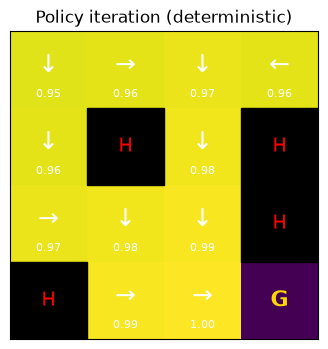

In [41]:
# run policy iteration on the deterministic env
policy, V = policy_iteration(env, gamma=0.99)

# show the learned policy with its values
show_policy(policy, V, env, title="Policy iteration (deterministic)")

In [42]:
# sanity check: optimal path is 6 steps, reward 1 at the end → V(start) = gamma^5
assert np.isclose(V[0], 0.99 ** 5, atol=1e-6), V[0]
print("V(start) ✓", V[0])

V(start) ✓ 0.9509900498999999


**What I see:** the values grow as I get closer to the goal. Each state's value is $\gamma^{(\text{steps to goal} - 1)}$: state 14 (one step away) has value 1, and the start needs 6 steps with the reward on the 6th, so $V(\text{start}) = \gamma^5 = 0.99^5 \approx 0.951$. Holes and the goal itself have value 0 since nothing happens after them.

### Play the game with the learned policy

In [43]:
# reset, then follow the policy step by step, printing the board, until the episode ends
state, _ = env.reset()
print_board(env, state)
done = False
while not done:
    state, reward, terminated, truncated, _ = env.step(int(policy[state]))
    done = terminated or truncated
    print_board(env, state)
print("Final reward:", reward)

A F F F
F H F H
F F F H
H F F G 

S F F F
A H F H
F F F H
H F F G 

S F F F
F H F H
A F F H
H F F G 

S F F F
F H F H
F A F H
H F F G 

S F F F
F H F H
F F F H
H A F G 

S F F F
F H F H
F F F H
H F A G 

S F F F
F H F H
F F F H
H F F A 

Final reward: 1


## 11. Policy iteration: stochastic implementation

Now `P[s][a]` has several possible outcomes, so we sum over all of them:

$$
v_{k+1}(s) = \sum_{(p,\, s',\, r) \in P[s][\pi(s)]} p\,\big[r + \gamma\, v_k(s')\big], \qquad
q(s, a) = \sum_{(p,\, s',\, r) \in P[s][a]} p\,\big[r + \gamma\, v(s')\big]
$$

This version works for the deterministic case too (a single outcome with $p = 1$).

In the deterministic case I only looked at `P[s][a][0]`, since there was one outcome. On the slippery lake an action can land me in 3 different places, so the value of a state becomes the **probability-weighted average** over all of them. That's exactly the $\sum_{s', r} p(s', r \mid s, a)[\dots]$ from the Bellman equation, written out as a loop.

In [44]:
def policy_evaluation(policy, env, gamma=0.99, max_iterations=1000, tol=1e-10):
    # V = zeros
    V = np.zeros(env.observation_space.n)
    mdp = env.unwrapped.P

    for i in range(max_iterations):
        # copy of old V
        V_old = V.copy()

        # for each state
        for s in range(env.observation_space.n):
            a = int(policy[s])
            # start the sum from 0 for this state
            v_s = 0
            for p, next_s, reward, terminated in mdp[s][a]:
                v_s += p * (reward + gamma * V_old[next_s])
            V[s] = v_s

        # stop if max change < tol
        if np.max(np.abs(V - V_old)) < tol:
            break
    return V

In [45]:
def policy_improvement(V, env, gamma=0.99):
    # new policy array (integer actions)
    new_policy = np.zeros(env.observation_space.n, dtype=int)
    mdp = env.unwrapped.P

    for s in range(env.observation_space.n):
        # Q of each action = sum over outcomes of p * (r + gamma * V[s_next])
        q = []
        for a in range(env.action_space.n):
            q_sa = sum(p * (r + gamma * V[next_s]) for p, next_s, r, terminated in mdp[s][a])
            q.append(q_sa)

        # greedy action
        new_policy[s] = int(np.argmax(q))

    # return new policy
    return new_policy

Converged after 4 improvement steps


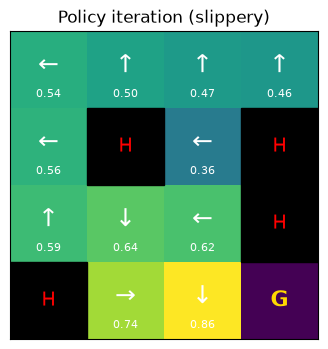

In [46]:
# policy iteration on the slippery env (policy_iteration from above reuses the new functions)
policy_slip, V_slip = policy_iteration(env_slip, gamma=0.99)

# show policy + values
show_policy(policy_slip, V_slip, env_slip, title="Policy iteration (slippery)")

### Testing the policy

Run many games and count how often we reach the goal. Because of the slipperiness, even the optimal policy only succeeds about **74%** of the time.

In [47]:
def test_policy(policy, env, num_episodes=1000):
    # count successes
    successes = 0

    # loop over episodes
    for _ in range(num_episodes):
        # reset env
        state, _ = env.reset()
        done = False

        # follow the policy until terminated or truncated
        while not done:
            state, reward, terminated, truncated, _ = env.step(int(policy[state]))
            done = terminated or truncated

        # success if final reward == 1
        successes += (reward == 1)

    # print and return success rate
    rate = successes / num_episodes
    print(f"Success rate: {rate:.1%}")
    return rate

In [48]:
# success rate of the slippery policy
test_policy(policy_slip, env_slip)

Success rate: 73.3%


0.733

**What I see:** around 74% success, which is basically the best possible here since I only move where I want 1/3 of the time.

The slippery policy looks weird at first: at some states it points **away** from the goal, or into a wall. That's on purpose. If moving toward the goal risks sliding sideways into a hole, it's better to pick an action whose possible slides can't reach a hole, even if it's slower. The policy trades speed for safety.

## 12. Recap

**Key takeaways:**
- An MDP defines the rules of the game: states, actions, and $p(s', r \mid s, a)$. The Markov property (only the present matters) is what makes everything recursive.
- The value of a state is the **expected** discounted return under a fixed policy. The Bellman equation writes it recursively: expected reward now + discounted value of where I land.
- The optimal values come from replacing the average over actions with a **max**. In $v_*$ the max is over the current action; in $q_*$ it's over the next action.
- Policy iteration alternates **evaluation** (iterate the Bellman expectation equation until $V$ converges) and **improvement** (act greedily on Q). It stops when the policy stops changing, and that policy is optimal.
- Stochastic environments just mean summing over every possible outcome, weighted by its probability.

**Limitation → what's next:** policy iteration evaluates every policy fully before improving it, which is a lot of sweeps. Value iteration merges both steps into a single update by putting the max inside every sweep.